# Comparación jerárquica de modelos entrenados

Este notebook carga **todos** los modelos entrenados en `artifacts/models/` (uno por
nivel de agregación M5: total, dept, store, store×dept) y compara sus predicciones
sobre el mismo período de test.

La pregunta de fondo: para un nivel de agregación dado (p.ej. el total de ventas),
¿es mejor pronosticarlo **directamente** con el modelo entrenado en ese nivel, o
**sumarlo (bottom-up)** a partir de las predicciones de un modelo entrenado en un
nivel más fino (dept, store, store×dept)? Y de paso, ¿combinar ambos enfoques
mejora el resultado?

Estructura:
1. Carga de artifacts + reconstrucción de test set + predicciones.
2. Tabla resumen de cada modelo en su propio nivel nativo.
3. Comparación al nivel **TOTAL**: modelo L1 directo vs. bottom-up desde L4/L6/L9,
   + una combinación simple (promedio) de todos.
4. Comparación a niveles intermedios: **dept** (L4 directo vs. bottom-up desde L9)
   y **store** (L6 directo vs. bottom-up desde L9).


In [1]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from loguru import logger

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

from src.data.split import reconstruct_test_data
from src.evaluation import build_predictions_report
from src.evaluation.point import bias, rmse, wape


## 1. Carga de artifacts, reconstrucción de test y predicciones

In [2]:
DIMS = ["dept_id", "cat_id", "store_id", "state_id"]


def load_level(artifact_path: Path) -> dict:
    '''Carga un artifact, reconstruye su X_test/train/test y arma el detalle de
    predicciones (df_pred) con las columnas de dimension (dept_id/store_id/...)
    pegadas desde X_test, para poder reagregar a cualquier nivel mas agregado.'''
    artifact = joblib.load(artifact_path)
    model = artifact["model"]

    X_test, y_test, train, test = reconstruct_test_data(artifact)
    y_pred = model.predict(X_test)

    metrics, df_pred = build_predictions_report(
        train, test, y_test, y_pred, target_col=artifact["target"],
    )
    dims_available = [d for d in DIMS if d in X_test.columns]
    df_pred = df_pred.join(X_test[dims_available])

    return {
        "level_id": artifact["level_id"],
        "level": artifact["level"],
        "model_class": type(model).__name__,
        "n_series": df_pred["series_id"].nunique(),
        "metrics": metrics,
        "df_pred": df_pred,
    }


artifact_paths = sorted(Path("../artifacts/models").glob("*_artifact.pkl"))
logger.info("Artifacts encontrados: {}", [p.name for p in artifact_paths])

LEVELS = {}
for path in artifact_paths:
    result = load_level(path)
    LEVELS[result["level_id"]] = result
    logger.info(
        "{} | {} series | modelo={} | WAPE test={:.2%} | WRMSSE test={:.3f}",
        result["level"], result["n_series"], result["model_class"],
        result["metrics"]["wape"], result["metrics"]["wrmsse"],
    )


2026-09-03 21:47:18.390 | INFO     | __main__:<module>:31 - Artifacts encontrados: ['level_01_daily_total_sales_artifact.pkl', 'level_04_daily_dept_sales_artifact.pkl', 'level_06_daily_store_sales_artifact.pkl', 'level_09_daily_store_dept_sales_artifact.pkl']


2026-09-03 21:47:18.651 | INFO     | src.data.split:load_data:359 - level_01_daily_total | target=sales | 1,941 filas | 191 features (9 categóricas)


2026-09-03 21:47:18.665 | INFO     | src.data.split:log_summary:48 - Train : 2011-01-29 to 2016-03-27 (1,885 days, 1,885 rows)


2026-09-03 21:47:18.667 | INFO     | src.data.split:log_summary:49 - Valid : 2016-03-28 to 2016-04-24 (28 days, 28 rows)


2026-09-03 21:47:18.668 | INFO     | src.data.split:log_summary:50 - Test  : 2016-04-25 to 2016-05-22 (28 days, 28 rows)


...

2026-09-03 21:47:21.105 | INFO     | src.data.split:log_summary:48 - Train : 2011-01-29 to 2016-03-27 (1,885 days, 131,950 rows)


2026-09-03 21:47:21.107 | INFO     | src.data.split:log_summary:49 - Valid : 2016-03-28 to 2016-04-24 (28 days, 1,960 rows)


2026-09-03 21:47:21.108 | INFO     | src.data.split:log_summary:50 - Test  : 2016-04-25 to 2016-05-22 (28 days, 1,960 rows)


2026-09-03 21:47:23.275 | INFO     | src.data.split:split_data:421 - Features: 191 (9 categóricas)


2026-09-03 21:47:23.547 | INFO     | __main__:<module>:37 - level_09_daily_store_dept | 70 series | modelo=LGBMRegressor | WAPE test=10.99% | WRMSSE test=0.714


## 2. Resumen de cada modelo en su propio nivel nativo

In [3]:
summary_rows = []
for level_id, res in sorted(LEVELS.items()):
    m = res["metrics"]
    summary_rows.append({
        "level_id": level_id,
        "level": res["level"],
        "n_series": res["n_series"],
        "modelo": res["model_class"],
        "wape": m["wape"],
        "wrmsse": m["wrmsse"],
        "bias": m["bias"],
        "rmse": m["rmse"],
    })

df_summary = pd.DataFrame(summary_rows).set_index("level_id")
df_summary.style.format({"wape": "{:.2%}", "wrmsse": "{:.3f}", "bias": "{:.2%}", "rmse": "{:,.1f}"})


,level,n_series,modelo,wape,wrmsse,bias,rmse
level_id,,,,,,,
1,level_01_daily_total,1,LGBMRegressor,5.38%,0.568,-4.48%,"3,356.1"
4,level_04_daily_dept,7,LGBMRegressor,7.41%,0.665,-3.46%,740.0
6,level_06_daily_store,10,LGBMRegressor,6.34%,0.533,-3.37%,377.7
9,level_09_daily_store_dept,70,LGBMRegressor,10.99%,0.714,-2.77%,104.0


## 3. Comparación al nivel TOTAL

Se agregan (`groupby("date").sum()`) las predicciones de cada nivel a la serie
diaria total y se comparan contra el mismo real (`sales`), que por construcción es
idéntico en todos los niveles. También se arma una combinación simple: el
promedio de las 4 predicciones totales, como primer paso hacia una reconciliación
jerárquica más formal (bottom-up ya está acá; top-down por proporciones históricas
o MinT/optimal reconciliation -- p.ej. con `hierarchicalforecast` -- quedan como
extensión natural).

In [4]:
def aggregate_to_total(df_pred: pd.DataFrame) -> pd.DataFrame:
    agg = df_pred.groupby("date").agg(actual=("sales", "sum"), y_pred=("y_pred", "sum"))
    return agg


LEVEL_LABELS = {
    1: "L1 total (directo)",
    4: "L4 dept (bottom-up)",
    6: "L6 store (bottom-up)",
    9: "L9 store×dept (bottom-up)",
}

total_aggs = {level_id: aggregate_to_total(res["df_pred"]) for level_id, res in LEVELS.items()}

df_total = pd.DataFrame({"actual": next(iter(total_aggs.values()))["actual"]})
for level_id, agg in sorted(total_aggs.items()):
    df_total[LEVEL_LABELS[level_id]] = agg["y_pred"]

# combinación naive: promedio de las predicciones de todos los niveles disponibles
pred_cols = [c for c in df_total.columns if c != "actual"]
df_total["Promedio de niveles"] = df_total[pred_cols].mean(axis=1)

df_total.round(0).head()


,actual,L1 total (directo),L4 dept (bottom-up),L6 store (bottom-up),L9 store×dept (bottom-up),Promedio de niveles
date,,,,,,
2016-04-25,38793.0,37911.0,37892.0,37101.0,36862.0,37442.0
2016-04-26,35487.0,33986.0,34997.0,34110.0,33966.0,34265.0
2016-04-27,34445.0,33209.0,34349.0,33813.0,33721.0,33773.0
2016-04-28,34732.0,34946.0,35850.0,34718.0,34847.0,35090.0
2016-04-29,42896.0,44455.0,42837.0,44272.0,43043.0,43652.0


In [5]:
rows = []
for col in [c for c in df_total.columns if c != "actual"]:
    y_true, y_pred = df_total["actual"], df_total[col]
    rows.append({
        "enfoque": col,
        "wape": wape(y_true, y_pred),
        "bias": bias(y_true, y_pred),
        "rmse": rmse(y_true, y_pred),
    })

df_total_metrics = pd.DataFrame(rows).sort_values("wape").reset_index(drop=True)
df_total_metrics.style.format({"wape": "{:.2%}", "bias": "{:.2%}", "rmse": "{:,.1f}"}).background_gradient(
    subset=["wape"], cmap="RdYlGn_r"
)


,enfoque,wape,bias,rmse
0,L9 store×dept (bottom-up),3.37%,-2.77%,"2,265.8"
1,Promedio de niveles,4.01%,-3.52%,"2,587.4"
2,L6 store (bottom-up),4.14%,-3.37%,"2,505.5"
3,L4 dept (bottom-up),4.18%,-3.46%,"2,644.0"
4,L1 total (directo),5.38%,-4.48%,"3,356.1"


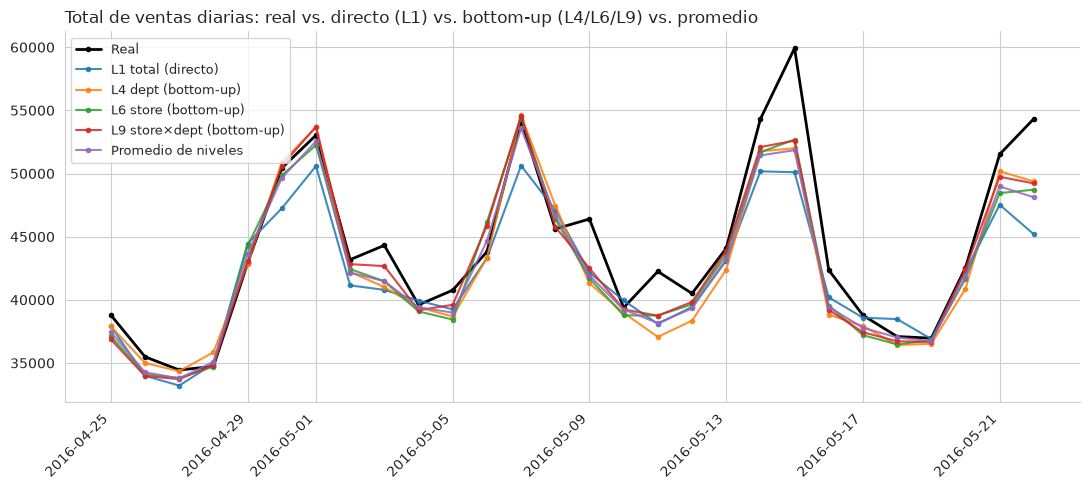

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df_total.index, df_total["actual"], label="Real", color="black", linewidth=2, marker="o", markersize=3)
for col in [c for c in df_total.columns if c != "actual"]:
    ax.plot(df_total.index, df_total[col], label=col, alpha=0.85, marker="o", markersize=3)

ax.set_title("Total de ventas diarias: real vs. directo (L1) vs. bottom-up (L4/L6/L9) vs. promedio", loc="left")
ax.set_xlabel("")
ax.legend(loc="upper left", fontsize=9)
plt.xticks(rotation=45, ha="right")
sns.despine()
plt.tight_layout()
plt.show()


## 4. Comparación a niveles intermedios

Mismo ejercicio pero un escalón más abajo del total: para cada **dept** y cada
**store**, ¿el modelo entrenado directamente en ese nivel (L4/L6) le gana al
modelo más fino (L9 store×dept) sumado (bottom-up) hasta ese nivel?

In [7]:
def compare_direct_vs_bottomup(direct_res: dict, fine_res: dict, group_col: str) -> pd.DataFrame:
    '''WAPE/bias por grupo (dept_id o store_id) comparando el modelo directo de ese
    nivel contra el bottom-up (agregado) del modelo del nivel mas fino.'''
    direct = direct_res["df_pred"]
    fine_agg = (
        fine_res["df_pred"]
        .groupby([group_col, "date"])
        .agg(sales=("sales", "sum"), y_pred=("y_pred", "sum"), gross_sales=("gross_sales", "sum"))
        .reset_index()
    )

    def _metrics(df):
        return pd.Series({
            "wape": wape(df["sales"], df["y_pred"]),
            "bias": bias(df["sales"], df["y_pred"]),
            "gross_sales": df["gross_sales"].sum(),
        })

    direct_m = direct.groupby(group_col).apply(_metrics, include_groups=False)
    fine_m = fine_agg.groupby(group_col).apply(_metrics, include_groups=False)

    out = direct_m[["wape", "bias"]].add_suffix("_directo").join(
        fine_m[["wape", "bias"]].add_suffix("_bottomup")
    ).join(direct_m["gross_sales"])
    out["gana_bottomup"] = out["wape_bottomup"] < out["wape_directo"]
    return out.sort_values("gross_sales", ascending=False)


df_dept_compare = compare_direct_vs_bottomup(LEVELS[4], LEVELS[9], "dept_id")
df_dept_compare.style.format({
    "wape_directo": "{:.2%}", "wape_bottomup": "{:.2%}",
    "bias_directo": "{:.2%}", "bias_bottomup": "{:.2%}",
    "gross_sales": "{:,.0f}",
})


,wape_directo,bias_directo,wape_bottomup,bias_bottomup,gross_sales,gana_bottomup
dept_id,,,,,,
FOODS_3,5.09%,-4.16%,3.70%,-2.10%,"1,379,273",True
HOUSEHOLD_1,5.21%,-0.23%,4.53%,-1.00%,"870,851",True
FOODS_2,7.99%,-3.56%,6.95%,-3.89%,"572,857",True
HOBBIES_1,7.37%,-1.79%,6.80%,-6.20%,"475,887",True
HOUSEHOLD_2,4.15%,-0.40%,3.54%,-2.77%,"291,483",True
FOODS_1,18.69%,-18.69%,17.48%,-17.48%,"283,273",True
HOBBIES_2,63.74%,63.74%,94.19%,92.49%,"27,352",False


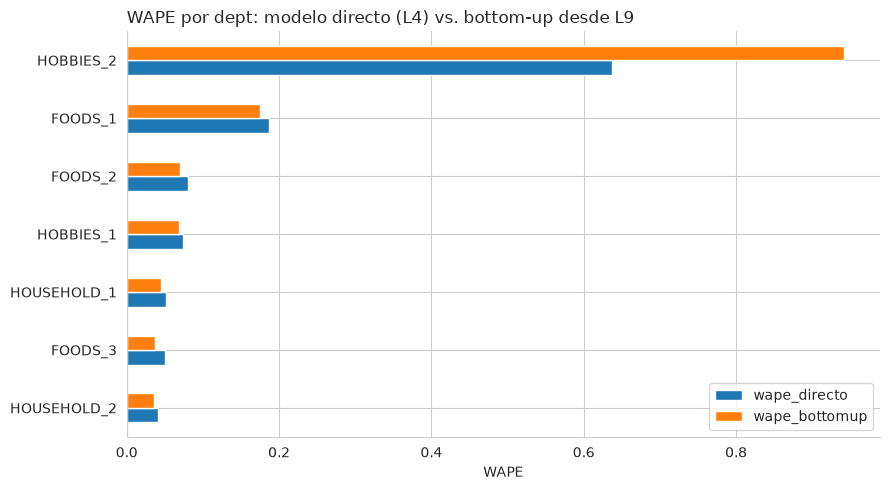

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = df_dept_compare[["wape_directo", "wape_bottomup"]].sort_values("wape_directo")
plot_df.plot(kind="barh", ax=ax)
ax.set_title("WAPE por dept: modelo directo (L4) vs. bottom-up desde L9", loc="left")
ax.set_xlabel("WAPE")
ax.set_ylabel("")
sns.despine()
plt.tight_layout()
plt.show()


In [9]:
df_store_compare = compare_direct_vs_bottomup(LEVELS[6], LEVELS[9], "store_id")
df_store_compare.style.format({
    "wape_directo": "{:.2%}", "wape_bottomup": "{:.2%}",
    "bias_directo": "{:.2%}", "bias_bottomup": "{:.2%}",
    "gross_sales": "{:,.0f}",
})


,wape_directo,bias_directo,wape_bottomup,bias_bottomup,gross_sales,gana_bottomup
store_id,,,,,,
CA_3,5.74%,-2.86%,4.43%,0.24%,"590,418",True
WI_2,7.35%,-4.39%,7.92%,-3.93%,"441,247",False
CA_2,6.82%,-4.92%,7.53%,-6.89%,"438,765",False
CA_1,4.72%,-2.68%,4.85%,-3.29%,"434,031",False
TX_3,7.96%,-6.54%,9.16%,-8.46%,"393,571",False
TX_2,6.43%,-3.45%,5.57%,-0.64%,"374,765",True
WI_1,6.47%,-3.50%,4.82%,-2.39%,"338,199",True
WI_3,5.56%,-1.69%,5.16%,0.32%,"323,220",True
TX_1,6.63%,-2.67%,5.97%,-1.89%,"308,179",True


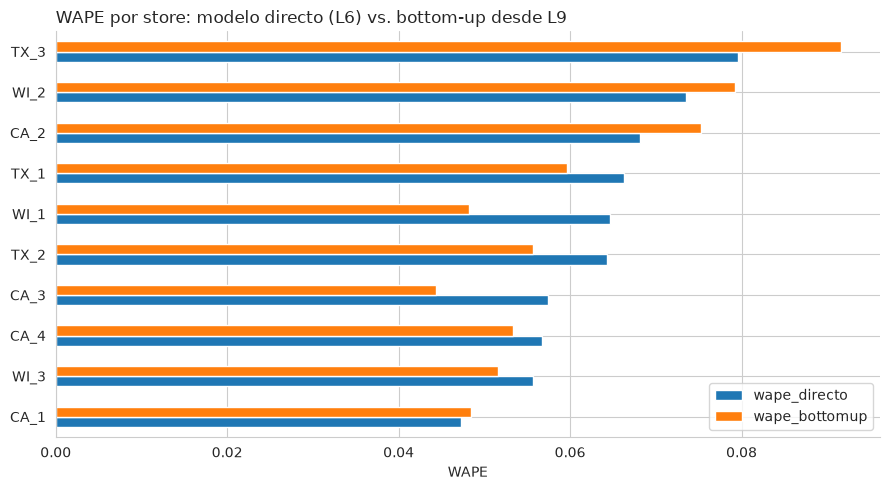

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = df_store_compare[["wape_directo", "wape_bottomup"]].sort_values("wape_directo")
plot_df.plot(kind="barh", ax=ax)
ax.set_title("WAPE por store: modelo directo (L6) vs. bottom-up desde L9", loc="left")
ax.set_xlabel("WAPE")
ax.set_ylabel("")
sns.despine()
plt.tight_layout()
plt.show()


## Conclusiones rápidas

- Revisar `df_total_metrics`: si "Promedio de niveles" queda por debajo del mejor
  enfoque individual, hay señal de que combinar información de distintos niveles
  de agregación reduce error -- la motivación estándar detrás de la reconciliación
  jerárquica (bottom-up, top-down, MinT).
- `df_dept_compare` / `df_store_compare` (columna `gana_bottomup`) muestran, serie
  por serie, si conviene más el modelo especializado en ese nivel o la suma desde
  el nivel más fino -- normalmente depende de cuánta señal específica del grupo
  (dept/store) exista vs. cuánta información se gana de tener series individuales
  más finas para el modelo de L9.
- Extensión natural: formalizar esto con reconciliación óptima (p.ej.
  `hierarchicalforecast` de Nixtla, que ya cubre bottom-up/top-down/MinT sobre esta
  misma estructura de niveles).
